In [1]:
# This file is part of SRO_related and is licensed under the GNU General Public License v3.0.
# See the LICENSE file in the root directory of this source tree or visit http://www.gnu.org/licenses/gpl-3.0.html.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from itertools import product
import scipy
from scipy.optimize import curve_fit
import os
import copy
import matplotlib
import math
from scipy.fftpack import fft2, ifft2, fftshift, ifftshift
from scipy.signal import find_peaks
from scipy.linalg import null_space
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from cuml.cluster import KMeans as KMeans_cu
from itertools import combinations
from IPython.display import clear_output
import multiprocessing as mp
from PIL import Image, ImageDraw
from functools import partial
import cupy as cp
from datetime import datetime

In [154]:
img_ind = '1_strengthening' #! First determine the INDEX
img_denote = '-filter'
# pth_load = f'{img_ind}/{img_ind}_raw.bmp'
pth_load = f'CrCoNi-231101/{img_ind}/{img_ind}{img_denote}.png'

img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)

#* Split the image into 9 parts
split_length = 700
for i, j in product(range(3), repeat=2):
    img_s = img[i*split_length:(i+1)*split_length, j*split_length:(j+1)*split_length]
    cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}{img_denote}_{i}{j}.bmp', img_s)
# cv2.imshow('img', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In the first step, define the bond lengths of polygons manually. Practically, this involves specifying the $\theta$ and two bond lengths for triangles.

- Detect peaks in the raw image: yield $R_{raw}$;
- Identify peaks in the image post-1d convolution; utilizing $[R_{raw}-t, R_{raw}+t]$, this step establishes the pattern's boundary.

In [2]:
def edge_peak_find(seq, zero_length, peak_length):
    ''' 
    zero_length: length of zero intensity region
    peak_length: length of peak intensity region
    '''
    left_bound, right_bound = [], []
    
    for i in range(len(seq)):
        if seq[i] == 0:
            continue
        
        zero_kernel_left = seq[i-zero_length:i]
        zero_kernel_right = seq[i+1:i+1+zero_length]
        
        peak_kernel_left = seq[i-peak_length:i]
        peak_kernel_right = seq[i+1:i+1+peak_length]
        
        if np.std(zero_kernel_left) < 0.01 and len(np.where(peak_kernel_right<0)[0]) > 0:
            left_bound.append(i)
        
        elif np.std(zero_kernel_right) < 0.01 and len(np.where(peak_kernel_left<0)[0]) > 0:
            right_bound.append(i)
            
    return left_bound, right_bound

def find_nearest(a1_, a2_):
    
    if len(a1_) == 0 or len(a2_) == 0:
        return []
    
    a1_ = np.array(a1_)
    a2_ = np.array(a2_)
    a1 = a1_.reshape(-1,1)
    a2 = a2_.reshape(1,-1)
    d_a_mat = a1-a2 

    pair_idx = np.concatenate(
        [a1_.reshape(-1,1), 
         a2_[np.argmin(np.abs(d_a_mat), axis = 1)].reshape(-1,1)], 
        axis = 1
    )
    return pair_idx

def conv1d(x, h):
    len_h = len(h)
    len_x = len(x)
    x_conv = np.zeros(len_x+len_h-1)
    
    for i in range(len(x_conv)):
        for j in range(len_h):
            if i-j < 0 or i-j >= len_x:
                continue 
            x_conv[i] += x[i-j]*h[j]
    
    return x_conv

img_ind = '1' #! INDEX determined at first
img_denote = '-filter2'
split_ind = '_22'
pth_load = f'CrCoNi-231101/{img_ind}/{img_ind}{img_denote}{split_ind}.bmp'

img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)

#TODO filtering

filter_dot_threshold = 10 #TODO Remove the low-intensity dots
img[img<filter_dot_threshold] = 0

kernel = np.array([1,-2,1,])
len_kernel = len(kernel)
nn_pair_buffer = [] #* [[[left_bound, right_bound, mean], ...] -> i, ...]
nn_pair_centre = np.empty((0,2)) #* [[i, centre], ...]
nn_pair_leftright = np.empty((0,4)) #* [[i, left, right, centre], ...]

for i in range(img.shape[0]):
    conv_img = conv1d(img[i], kernel)[len_kernel//2:-len_kernel//2+1]

    left_bound, right_bound = edge_peak_find(conv_img, 1, 3) #TODO change zero length
    nn_pair = find_nearest(left_bound, right_bound)
    if len(nn_pair) == 0:
        nn_pair_buffer.append(nn_pair)
        continue
    
    #* Remove the one-dot pattern 
    # nn_pair_diff = np.abs(nn_pair[:,0]-nn_pair[:,1])
    # nn_pair = nn_pair[nn_pair_diff>2]
    
    nn_centre = np.mean(nn_pair, axis=1).reshape(-1,1)
    nn_pair = np.column_stack((nn_pair, nn_centre))
    nn_pair_buffer.append(nn_pair)
    
    #* Create [i, centre] mat
    i_leftright_mat = np.column_stack((np.ones(len(nn_pair))*i, nn_pair))
    i_centre_mat = np.column_stack((np.ones(len(nn_centre))*i, nn_centre))
    nn_pair_centre = np.concatenate((nn_pair_centre, i_centre_mat), axis=0)
    nn_pair_leftright = np.concatenate((nn_pair_leftright, i_leftright_mat), axis=0)
    
print('done at', datetime.now().strftime("%Y-%m-%d %H:%M"))

/home/wz/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/wz/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/wz/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done at 2023-11-19 20:24


In [174]:

#! For test: check sufficiency of the nn_pair_buffer
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

radius = 2
color = (0,0,255)
thickness = 1
alpha=0.5
overlay = img_color.copy()

#* Draw rectangle from the `max_search` function
for (x, y) in nn_pair_centre:
    x, y =  int(round(x, 0)), int(round(y, 0))
    cv2.circle(img_color, (y,x), radius, color, thickness)
    
cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0, img_color)

cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}_test.bmp', img_color)
# np.save(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}_test.npy', centre_list)
# cv2.imshow('DODODO', img_color)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

True

In [32]:
np.savetxt(f'CrCoNi-231101/{img_ind}/nn_pair_leftright.txt', nn_pair_leftright.astype(int), fmt='%i')

In [448]:

#TODO clustering of the nn_pair_buffer
pix_threshold = 12 #* Max radius of dot
half_pix_threshold = 8 #* Interval for shape[0]
cluster = []
img_divide = [np.unique(np.clip(np.arange(
                    half_pix_threshold*i, 
                    half_pix_threshold*i+pix_threshold), None, img.shape[0]-1))
              for i in range(0, img.shape[0]//half_pix_threshold+1)]

centre_list = np.empty((0,2))
j_list = [] #* Check the number of clusters in each block
for i in range(len(img_divide)):
    img_cluster_x = img_divide[i]
    cluster_ = np.concatenate([
        nn_pair_leftright[np.where(nn_pair_leftright[:,0] == j)[0]]
        for j in img_cluster_x], axis=0)
    
    #* Do k-means on centre 
    left_list = cluster_[:,[0,1]]
    right_list = cluster_[:,[0,2]]
    bound_list = np.concatenate([left_list, right_list], axis=0)

    if len(bound_list) == 0:
        continue
    
    wcss = []
    # bound_list = cp.asarray(bound_list)
    max_clusters = min([len(bound_list), 80]) #TODO setting for max_clusters
    inertia_raw = 1e3
    
    if img_denote == '-raw':
        j_min = 55
    elif img_denote == '-filter2':
        j_min = 2
    else:
        j_min = 2
    
    for j in range(j_min, max_clusters+1):
        kmeans = KMeans(n_clusters=j, n_init=j,)
        kmeans.fit(bound_list)
        inertia_ = kmeans.inertia_
        d_inertia = np.abs(inertia_ - inertia_raw)
        if d_inertia < 4: #TODO setting for tolerance of inertia
            break
        inertia_raw = inertia_
    
    j_list.append(j)
    cluster_centre = kmeans.cluster_centers_
    centre_list = np.concatenate((centre_list, cluster_centre), axis=0)

    # clear_output(wait=True)
    if i % 10 == 0:
        clear_output(wait=True)
        print(f'Finish {np.round(i/len(img_divide)*100, 1)}%')

print('done at', datetime.now().strftime("%Y-%m-%d %H:%M"))

Finish 0.0%
Finish 12.2%
Finish 24.4%
Finish 36.6%
Finish 48.8%
Finish 61.0%
Finish 73.2%
Finish 85.4%
done at 2023-11-11 17:05


In [36]:
np.savetxt(f'CrCoNi-231101/{img_ind}/centre_list_kmeans.txt', 
           centre_list[np.argsort(centre_list[:,0])], fmt='%i')

- Retain centroids that are similar if $d < \epsilon_d$.
- Filter *both* unique and similar centroids to confirm:
  - Each dot corresponds to a single centroid.
  - Centroids are precisely positioned at the correct locations.

In [449]:
threshold_centre = 0 #TODO change this? (8 better than 10)
buffer_similarcentre = []
ind_allsimilar = np.empty(0)

#* Use multi-processing to generate distance matrix 
def main(i):
    i1, i2 = combinatorial_ind[i]
    dis = np.linalg.norm(centre_list[i1]-centre_list[i2])
    return dis

combinatorial_ind = np.array(list(combinations(range(len(centre_list)), 2)))
n_core = 20 #* number of cores
with mp.Pool(n_core) as p:
    dis_list_raw = np.array(p.map(main, range(combinatorial_ind.shape[0])))

dis_mat = np.zeros((len(centre_list), len(centre_list)))
dis_mat[combinatorial_ind[:,0], combinatorial_ind[:,1]] = dis_list_raw
dis_mat[combinatorial_ind[:,1], combinatorial_ind[:,0]] = dis_list_raw
print('Finish distance matrix')

for comb_i in range(len(combinatorial_ind)):
    
    i, j = combinatorial_ind[comb_i]
    # dis = np.linalg.norm(centre_list[i]-centre_list[j])
    dis = dis_mat[i,j]
    
    if dis > threshold_centre:
        continue
    
    ind_allsimilar = np.unique(np.concatenate((ind_allsimilar, np.array([i,j])), axis=0))
        
    if len(buffer_similarcentre) == 0:
        buffer_similarcentre.append(np.array([i,j]))
        continue
    
    unic_ij = False
    for k in range(len(buffer_similarcentre)):
        buffer_ = buffer_similarcentre[k]
        if np.isin(np.array([i,j]), buffer_).any():
            buffer_similarcentre[k] = np.unique(np.concatenate((buffer_, np.array([i,j])), axis=0))
            unic_ij = True
            break
    
    if not unic_ij:
        buffer_similarcentre.append(np.array([i,j]))
        
    if comb_i % 10000 == 0:
        print(f'Finish {np.round(comb_i/len(combinatorial_ind)*100, 1)}%')

print('merge of similar centroids done')

def bivariate_gs(rho, std_x, std_y, mu_x, mu_y, x, y):
    norm_term = 1/(2*np.pi*std_x*std_y*np.sqrt(1-rho**2))
    exp_term = np.exp(-1/(2*(1-rho**2))*(
        ((x-mu_x)/std_x)**2 + ((y-mu_y)/std_y)**2 - 2*rho*(x-mu_x)*(y-mu_y)/(std_x*std_y)
    ))
    return norm_term*exp_term

def maha_dist(x_, mu_, cov):
    return np.dot(np.dot((x_-mu_), np.linalg.inv(cov)), (x_-mu_).T)

def softmax(x):
    return np.exp(x)/np.sum(np.exp(x))

def max_search(raw_p, img_):
    
    img = img_.copy()
    img = (img - np.mean(img))/np.std(img)
    raw_p = np.round(raw_p, 0).astype(int)
    #* Record the trajectory and return the best one
    best_int = -1
    global_x_min, global_x_max, global_y_min, global_y_max = \
        img.shape[0], 0, img.shape[1], 0
    for _ in range(100): 
        p_searchmat = np.clip(
            #TODO determine the search area
            np.array([raw_p+np.array([i,j]) for i in range(-1,2) for j in range(-1,2)]),
            0, np.array(img.shape)-1 #* what's the optimized search area
        )
        
        p_searchintensity = img[p_searchmat[:,0], p_searchmat[:,1]]
        p_searchintensity_raw = img_[p_searchmat[:,0], p_searchmat[:,1]]
        zero_ind = np.where(p_searchintensity_raw == 0)[0]
        prob_ = softmax(p_searchintensity)
        prob_[zero_ind] = 0
        if np.sum(prob_) == 0:
            prob_ = np.ones(len(p_searchmat))/len(p_searchmat)
        prob_ = prob_/np.sum(prob_)

        max_intensity_ind = np.random.choice(range(len(p_searchmat)), p=prob_)
        raw_p = p_searchmat[max_intensity_ind]
        
        int_ = np.sum(p_searchintensity_raw)
        if int_ > best_int:
            best_int = int_
            best_p = raw_p
        
        #* Store the x_min, x_max, y_min, y_max to draw rectangle
        valid_ind = np.where(p_searchintensity_raw != 0)[0]
        if len(valid_ind) == 0:
            continue
        
        x_min, x_max = np.min(p_searchmat[valid_ind][:,0]), np.max(p_searchmat[valid_ind][:,0])
        y_min, y_max = np.min(p_searchmat[valid_ind][:,1]), np.max(p_searchmat[valid_ind][:,1])
        
        if x_min < global_x_min:
            global_x_min = x_min
        if x_max > global_x_max:
            global_x_max = x_max
        if y_min < global_y_min:
            global_y_min = y_min
        if y_max > global_y_max:
            global_y_max = y_max
        
    # return best_p.reshape(1,-1)
    return np.array([global_x_min, global_y_min, global_x_max, global_y_max,
                (global_x_max+global_x_min)/2, (global_y_max+global_y_min)/2]).reshape(1,-1)
    
# #* Merge similar centre
centre_list_asind = np.round(centre_list, 0).astype(int)
intensity_list = np.array([
    img[centre_list_asind[i][0], centre_list_asind[i][1]] for i in range(len(centre_list))
])

old_centre_uniq = centre_list[[i for i in range(len(centre_list)) if i not in ind_allsimilar]]
#* Also calibrate the unic centroids.
old_centre_uniq_ = np.empty((0,6))
for old_centre_ in old_centre_uniq:
    k_old_centre_ = max_search(old_centre_, img)
    old_centre_uniq_ = np.concatenate((old_centre_uniq_, k_old_centre_), axis=0)
old_centre_uniq = old_centre_uniq_.copy()

new_centre_add, prob_buffer, maha_buffer = [], [], []

for i in range(len(buffer_similarcentre)): #* do a p-test on 2d gaussian
    
    kmeans = KMeans(n_clusters=1, n_init=1)
    
    #? New stratege: times the intensity as weight (apply softmax)
    similar_inds = buffer_similarcentre[i]
    intensity_group = intensity_list[similar_inds]
    
    centre_group = centre_list[similar_inds]
    
    if len(centre_group) == 0:
        continue
    
    k_centre = kmeans.fit(centre_group).cluster_centers_
    
    if len(centre_group) == 1:
        k_centre = max_search(k_centre[0], img)
        new_centre_add.append(k_centre)
        continue
    
    x_, y_ = centre_group[:,0], centre_group[:,1]
    k_x, k_y = k_centre[0][0], k_centre[0][1]
    std_x, std_y = np.sqrt(np.sum((x_-k_x)**2)/len(x_)), np.sqrt(np.sum((y_-k_y)**2)/len(y_))
    rho = np.sum((x_-k_x)*(y_-k_y))/np.sqrt(np.sum((x_-k_x)**2)*np.sum((y_-k_y)**2))
    cov = np.array([[std_x**2, rho*std_x*std_y], [rho*std_x*std_y, std_y**2]])
    
    prob_list = bivariate_gs(rho, std_x, std_y, k_x, k_y, x_, y_)
    prob_list = prob_list/np.sum(prob_list)
    
    outlier = np.where(prob_list < 0.05)[0]
    centre_group = np.delete(centre_group, outlier, axis=0)
    
    if len(centre_group) == 0:
        k_centre = max_search(k_centre[0], img)
        new_centre_add.append(k_centre)
        continue
    
    k_centre = kmeans.fit(centre_group).cluster_centers_
    k_centre = max_search(k_centre[0], img)
    new_centre_add.append(k_centre)
    prob_buffer.append(prob_list)
    # maha_buffer.append(maha_dist(centre_group, k_centre, np.cov(centre_group.T)))
    
new_centre_list = np.concatenate((old_centre_uniq, np.concatenate(new_centre_add, axis=0)), axis=0)
print('done at', datetime.now().strftime("%Y-%m-%d %H:%M"))

Finish distance matrix
done at 2023-11-11 17:05


Remove the duplicated centroids.

In [451]:
threshold_centre = 4 #TODO threshold for merging centroids
buffer_similarcentre = []
ind_all_similar = np.empty(0)
ind_raw_all = np.arange(len(new_centre_list))
centre_list_pair = new_centre_list[:,-2:]

#* Use multi-processing to generate distance matrix 
def main(i):
    i1, i2 = combinatorial_ind[i]
    dis = np.linalg.norm(centre_list_pair[i1]-centre_list_pair[i2])
    return dis

combinatorial_ind = np.array(list(combinations(range(len(centre_list_pair)), 2)))
n_core = 16 #* number of cores
with mp.Pool(n_core) as p:
    dis_list_raw = np.array(p.map(main, range(combinatorial_ind.shape[0])))

dis_mat = np.zeros((len(centre_list), len(centre_list)))
dis_mat[combinatorial_ind[:,0], combinatorial_ind[:,1]] = dis_list_raw
dis_mat[combinatorial_ind[:,1], combinatorial_ind[:,0]] = dis_list_raw
print('Finish distance matrix')

for i, j in combinations(range(len(new_centre_list)), 2):
    
    dis = dis_mat[i,j]
    if dis > threshold_centre:
        continue
    
    ind_all_similar = np.unique(np.concatenate((ind_all_similar, np.array([i,j])), axis=0))
    
    if len(buffer_similarcentre) == 0:
        buffer_similarcentre.append(np.array([i,j]))
        continue
    
    unic_ij = False
    for k in range(len(buffer_similarcentre)):
        buffer_ = buffer_similarcentre[k]
        if np.isin(np.array([i,j]), buffer_).any():
            buffer_similarcentre[k] = np.unique(np.concatenate((buffer_, np.array([i,j])), axis=0))
            unic_ij = True
            break
    
    if not unic_ij:
        buffer_similarcentre.append(np.array([i,j]))

ind_raw = np.delete(ind_raw_all, ind_all_similar.astype(int))
unic_ind = np.array([i[0] for i in buffer_similarcentre])
ind_new = np.concatenate((ind_raw, unic_ind), axis=0).astype(int)
new_centre_list = new_centre_list[ind_new]
print('done at', datetime.now().strftime("%Y-%m-%d %H:%M"))

Finish distance matrix
done at 2023-11-11 17:06


In [452]:
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

radius = 2
color = (0,0,255)
thickness = 1
alpha=0.5
overlay = img_color.copy()

# for (x, y) in new_centre_list:
#     x, y =  int(round(x, 0)), int(round(y, 0))
#     cv2.circle(img_color, (y,x), radius, color, thickness)

#* Draw rectangle from the `max_search` function
for (x_min, y_min, x_max, y_max) in new_centre_list[:,:4]:
    x_min, y_min, x_max, y_max = int(round(x_min, 0)), int(round(y_min, 0)), int(round(x_max, 0)), int(round(y_max, 0))
    cv2.rectangle(img_color, (y_min, x_min), (y_max, x_max), color, thickness)
    cv2.line(img_color, (y_min, x_min), (y_max, x_max), color, thickness)
    cv2.line(img_color, (y_min, x_max), (y_max, x_min), color, thickness)

cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0, img_color)

cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}{split_ind}.bmp', img_color)
np.save(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}{split_ind}.npy', new_centre_list)
# cv2.imshow('DODODO', img_color)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
print('done at', datetime.now().strftime("%Y-%m-%d %H:%M"))

done at 2023-11-11 17:06


Establish parallelogram and square shapes using $\theta$, and lengths $l_1, l_2$.

(quite rough and sluggish code though...)

In [123]:
 #* Angle for rhombic is: 35, 50, 90, 130, 145
theta_list = np.array([35, 50, 90, 130, 145])/180*np.pi
best_a = 19*np.sqrt(5)
b = [best_a-1, best_a+1]
for b_ in b:
    print(b_, np.sqrt(b_**2+b_**2-2*b_**2*np.cos(theta_list)))

41.48529157249601 [24.94973554 35.06488362 58.66906198 75.1968856  79.13045156]
43.48529157249601 [26.15255874 36.75535667 61.49748911 78.82211675 82.94531936]


In [191]:
# #* Special treatment: get the null space of the centroids matrix.
split_ind = '_22'
cent_all = np.load(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted-raw{split_ind}.npy')[:,-2:]
cent_filt = np.load(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted-filter2{split_ind}.npy')[:,-2:]

delete_ind = []
for i in range(len(cent_all)):
    dis_min = np.min(np.linalg.norm(cent_filt-cent_all[i], axis=1))
    if dis_min < 8:
        delete_ind.append(i)
        
new_centre_list = np.delete(cent_all, np.array(delete_ind), axis=0)

In [74]:
new_centre_list.shape, cent_all.shape

((186, 2), (1269, 2))

In [ ]:
def dot_in_tri(tri_coord, dot_, tol=-1e-2):
    
    dot = copy.deepcopy(dot_)
    # dot = np.concatenate((dot, dot_virtual), axis=0)
    t1, t2, t3 = tri_coord
    tri_bond_vector = np.array([t2-t1, t3-t1, t3-t2]) #* means the vertex is t3, t2, t1
    tri_bond_vector = tri_bond_vector/np.linalg.norm(tri_bond_vector, axis=1).reshape(-1,1)
    
    #* Projection of dot on each bond
    proj_coord_t1 = np.dot(dot-t1, tri_bond_vector[0])*tri_bond_vector[0]
    inner_dot_t3 = np.dot(proj_coord_t1-(dot-t1), proj_coord_t1-(t3-t1))
    proj_len_1 = np.linalg.norm(dot-(proj_coord_t1+t1))
    
    proj_coord_t3 = np.dot(dot-t3, tri_bond_vector[1])*tri_bond_vector[1]
    inner_dot_t2 = np.dot(proj_coord_t3-(dot-t3), proj_coord_t3-(t2-t3))
    proj_len_2 = np.linalg.norm(dot-(proj_coord_t3+t3))
    
    proj_coord_t2 = np.dot(dot-t2, tri_bond_vector[2])*tri_bond_vector[2]
    inner_dot_t1 = np.dot(proj_coord_t2-(dot-t2), proj_coord_t2-(t1-t2))
    proj_len_3 = np.linalg.norm(dot-(proj_coord_t2+t2))
    
    if np.min([proj_len_1, proj_len_2, proj_len_3]) < 0.08:
        return True
    #TODO determine the threshold for inner product
    elif np.min([inner_dot_t1, inner_dot_t2, inner_dot_t3]) > tol:
        return True
    else:
        return False
    
def c2_dot(dot, vec_vertices):
    ''' 
    return v' which is the dot after C2 operation
    '''
    v1, v2 = vec_vertices
    dot_c2 = v2 - (dot-v1)
    return dot_c2  
    
l_range = np.array([20,85]) #TODO lower and upper bounds for polygons, defined in above cell.
# l_range = np.array([12, 52])

theta_para_1_50 = 50/180*np.pi
theta_para_1_130 = 130/180*np.pi

theta_para_2_35 = 35/180*np.pi
theta_para_2_145 = 145/180*np.pi

square_para = 0.5*np.pi
threshold_length = 3 #TODO threshold for length difference
threshold_angle = 2
allow_dot_in_pattern = False #* allow dot in polygon, always False
# para_ind, square_ind = np.empty((0,2,2)), np.empty((0,2,2))
# img_ind = '01'
#! IF required, determine the INDEX
# img_ind = '3'
# img_denote = '-XYZ'
# img_denote = '-filter2'
# new_centre_list = np.load(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}.npy')[:,-2:]
# new_centre_list = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw.npy')
pth_load = f'CrCoNi-231101/{img_ind}/{img_ind}{img_denote}{split_ind}.bmp'
# pth_load = '/media/wz/7AD631A4D6316195/Projects/SRO_related/CrCoNi-231101/1/1-filter2.bmp'
img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)

load_dismat = False
if load_dismat:
    dis_matrix = np.load(f'{img_ind}_dis_matrix.npy')
else:
    
    #* Use multi-processing to generate distance matrix 
    def main(i):
        i1, i2 = combinatorial_ind[i]
        dis = np.linalg.norm(new_centre_list[i1]-new_centre_list[i2])
        return dis

    combinatorial_ind = np.array(list(combinations(range(len(new_centre_list)), 2)))
    n_core = 22 #* number of cores
    with mp.Pool(n_core) as p:
        dis_list_raw = np.array(p.map(main, range(combinatorial_ind.shape[0])))

    dis_matrix = np.zeros((len(new_centre_list), len(new_centre_list)))
    dis_matrix[combinatorial_ind[:,0], combinatorial_ind[:,1]] = dis_list_raw
    dis_matrix[combinatorial_ind[:,1], combinatorial_ind[:,0]] = dis_list_raw

    print('Finish dis_matrix')

grid_interval = np.max(l_range)
grid_num = int(np.ceil(np.max(img.shape)/grid_interval))
grid_x = np.linspace(0, img.shape[0], grid_num)
grid_y = np.linspace(0, img.shape[1], grid_num)
grid = np.array(list(product(grid_x, grid_y)))

mega_grid_interval = grid_interval*2
mega_grid_num = int(np.ceil(np.max(img.shape)/mega_grid_interval))
mega_grid_x = np.linspace(0, img.shape[0], mega_grid_num)
mega_grid_y = np.linspace(0, img.shape[1], mega_grid_num)
mega_grid = np.array(list(product(mega_grid_x, mega_grid_y)))
#* find the nearest megagrid for each grid and make a map
map_grid2mega = [None]*len(grid)
for i in range(len(grid)):
    dis = np.linalg.norm(mega_grid-grid[i], axis=1)
    ind = np.argsort(dis)[:4]
    map_grid2mega[i] = ind

#* Seperate the centre_list into NxN parts
centre_grids = [[] for _ in range(len(grid))]
centre_megagrids = [[] for _ in range(len(mega_grid))]
for i in range(len(new_centre_list)):
    centre_ = new_centre_list[i]
    dis = np.linalg.norm(grid-centre_, axis=1)
    valid_zone = np.where(dis <= np.max(l_range)*np.sqrt(2))[0]
    for j in valid_zone:
        centre_grids[j].append(i)
        for k in range(4):
            centre_megagrids[map_grid2mega[j][k]].append(i)

def angle_calc(a, b):
    return np.arccos(np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b)))

ind_map = {
    (0,1): [[1,0],[2,0]],
    (0,2): [[0,1],[2,1]],
    (1,2): [[0,2],[1,2]],
}

diff_bond_map = {
    0: [0,1],
    1: [0,2],
    2: [1,2],
}
      
#* Find the triangle config
count = 0
range_stop, length_stop, angle_stop, angle_buffer = 0, 0, 0, []
range_buffer, length_buffer = [], []
valid_length_buffer, valid_length_buffer_square = [], []
debug = False
if debug:
    centre_grids = centre_grids[:1000] 
    
def main_pattern_deduce(count):
    
    para_ind_35_true, para_ind_50_true, square_ind_true = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
    para_ind_35_virtual, para_ind_50_virtual, square_ind_virtual = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
    orient_35, orient_50, orient_square = [], [], []
    virtual_centre_list = np.empty((0,2))
    
    c_grid = centre_grids[count]
    mega_c_grid = np.unique(np.concatenate([np.array(centre_megagrids[i]) for i in map_grid2mega[count]])).astype(int)
    for i, j, k in combinations(c_grid, 3):
        
        ijk_ind = np.array([i,j,k])
        dis_list = [dis_matrix[i,j], dis_matrix[i,k], dis_matrix[j,k]]
        bond_discrimitive = np.array([
            np.prod(np.sign(dis_list[_]-l_range)) for _ in range(len(dis_list))
        ])
        
        ind_validbond = np.where(np.abs(bond_discrimitive+1)<1e-2)[0]
        #* Filter for range
        if len(ind_validbond) < 2:
            if debug:
                range_stop += 1
                range_buffer.append(dis_list)
            continue 
        
        #* Filter for equal length 
        dis_diff = np.abs(np.array([dis_list[d_i]-dis_list[d_j] for d_i, d_j in combinations(range(len(dis_list)), 2)]))
        ind_validlength = np.where(dis_diff < threshold_length)[0] #* Only one bond pair can be identical in length
        if len(ind_validlength) != 1:
            if debug:
                length_stop += 1
                length_buffer.append(dis_list)
            continue
        
        #* Filter for angle
        ind_map_ = ind_map[tuple(diff_bond_map[ind_validlength[0]])]
        bond_1, bond_2 = ind_map_[0], ind_map_[1]
        
        angle = angle_calc(new_centre_list[ijk_ind[bond_1[0]]]-new_centre_list[ijk_ind[bond_1[1]]], 
                    new_centre_list[ijk_ind[bond_2[0]]]-new_centre_list[ijk_ind[bond_2[1]]])
        
        vertex_ind = new_centre_list[ijk_ind[bond_1[1]]] #* Vertex for equal-length bond
        bot_ind = new_centre_list[np.array([ijk_ind[bond_1[0]], ijk_ind[bond_2[0]]])]
        vertex_2nd = c2_dot(vertex_ind, bot_ind)
        
        tri_coords_1, tri_coord_2 = \
            np.concatenate((vertex_ind.reshape(1,-1), bot_ind), axis=0), \
            np.concatenate((vertex_2nd.reshape(1,-1), bot_ind), axis=0)
            
        sav_coord = np.array([
            [vertex_ind, bot_ind[0]],
            [vertex_ind, bot_ind[1]],
            [vertex_2nd, bot_ind[0]],
            [vertex_2nd, bot_ind[1]],
        ])
        
        vec_coord = 1/2*(bot_ind[0]+bot_ind[1])-vertex_ind
                
        #TODO threshold for angle
        #? 50
        if (np.rad2deg(np.abs(angle-theta_para_1_50)) < threshold_angle 
            and np.max(dis_list) < 45
            and np.min(dis_list) > 34):
                        
            tri_ind = np.array([[i,j],[i,k],[j,k]])
            #* Check if any dot in the triangle, if so, remove it
            # tri_coords = new_centre_list[ijk_ind]
            dot_in_tri_list = []
            
            if not allow_dot_in_pattern:
                # for i_dot in mega_c_grid:
                for i_dot in range(len(new_centre_list)):
                    if i_dot in ijk_ind:
                        continue
                    
                    for tri_coords in [tri_coords_1, tri_coord_2]:
                        dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                            new_centre_list[i_dot]))
                
                if np.sum(dot_in_tri_list) > 0:
                    continue
                        
            para_ind_50_true = np.concatenate([para_ind_50_true, sav_coord[:2]], axis=0)
            para_ind_50_virtual = np.concatenate([para_ind_50_virtual, sav_coord[2:]], axis=0)
            orient_50.append(vec_coord)
            virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)
            
            valid_length_buffer.append(dis_list)
        
        #? 130
        elif (np.rad2deg(np.abs(angle-theta_para_1_130)) < threshold_angle 
              and np.max(dis_list) > 74
              and 40 < np.min(dis_list) < 45):
            
            tri_ind = np.array([[i,j],[i,k],[j,k]])
            #* Check if any dot in the triangle, if so, remove it
            # tri_coords = new_centre_list[ijk_ind]
            dot_in_tri_list = []
            
            if not allow_dot_in_pattern:
                # for i_dot in mega_c_grid:
                for i_dot in range(len(new_centre_list)):
                    if i_dot in ijk_ind:
                        continue
                    
                    for tri_coords in [tri_coords_1, tri_coord_2]:
                        dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                            new_centre_list[i_dot]))
            
                if np.sum(dot_in_tri_list) > 0:
                    continue
                         
            para_ind_50_true = np.concatenate([para_ind_50_true, sav_coord[:2]], axis=0)
            para_ind_50_virtual = np.concatenate([para_ind_50_virtual, sav_coord[2:]], axis=0)
            orient_50.append(vec_coord)
            virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)

            valid_length_buffer.append(dis_list)
            
        #? 35
        elif (np.rad2deg(np.abs(angle-theta_para_2_35)) < threshold_angle
            and np.max(dis_list) < 45
            and np.min(dis_list) > 23):
                        
            tri_ind = np.array([[i,j],[i,k],[j,k]])
            #* Check if any dot in the triangle, if so, remove it
            # tri_coords = new_centre_list[ijk_ind]
            dot_in_tri_list = []
            
            if not allow_dot_in_pattern:
                # for i_dot in mega_c_grid:
                for i_dot in range(len(new_centre_list)):
                    if i_dot in ijk_ind:
                        continue
                    
                    for tri_coords in [tri_coords_1, tri_coord_2]:
                        dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                            new_centre_list[i_dot]))
                
                if np.sum(dot_in_tri_list) > 0:
                    continue
                        
            para_ind_35_true = np.concatenate([para_ind_35_true, sav_coord[:2]], axis=0)
            para_ind_35_virtual = np.concatenate([para_ind_35_virtual, sav_coord[2:]], axis=0)
            orient_35.append(vec_coord)
            virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)

            valid_length_buffer.append(dis_list)
            
        #? 145
        elif (np.rad2deg(np.abs(angle-theta_para_2_145)) < threshold_angle 
            and np.min(dis_list) < 45
            and np.max(dis_list) > 78):
                        
            tri_ind = np.array([[i,j],[i,k],[j,k]])
            #* Check if any dot in the triangle, if so, remove it
            # tri_coords = new_centre_list[ijk_ind]
            dot_in_tri_list = []
            
            if not allow_dot_in_pattern:
                # for i_dot in mega_c_grid:
                for i_dot in range(len(new_centre_list)):
                    if i_dot in ijk_ind:
                        continue
                    
                    for tri_coords in [tri_coords_1, tri_coord_2]:
                        dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                            new_centre_list[i_dot]))
                
                if np.sum(dot_in_tri_list) > 0:
                    continue
                        
            para_ind_35_true = np.concatenate([para_ind_35_true, sav_coord[:2]], axis=0)
            para_ind_35_virtual = np.concatenate([para_ind_35_virtual, sav_coord[2:]], axis=0)
            orient_35.append(vec_coord)
            virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)
            
            valid_length_buffer.append(dis_list)
        
        #? Square
        elif (np.rad2deg(np.abs(angle-square_para)) < threshold_angle 
              and 63 > np.max(dis_list) > 56
              and 40 < np.min(dis_list) < 45):
                
            tri_ind = np.array([[i,j],[i,k],[j,k]])
            #* Check if any dot in the triangle, if so, remove it
            dot_in_tri_list = []
            
            if not allow_dot_in_pattern:
                # for i_dot in mega_c_grid:
                for i_dot in range(len(new_centre_list)):
                    if i_dot in ijk_ind:
                        continue
                    
                    for tri_coords in [tri_coords_1, tri_coord_2]:
                        dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                            new_centre_list[i_dot]))
                        
                #? tolerance for square should be as low as possible
                
                if np.sum(dot_in_tri_list) > 0:
                    continue
            
            square_ind_true = np.concatenate([square_ind_true, sav_coord[:2]], axis=0)
            square_ind_virtual = np.concatenate([square_ind_virtual, sav_coord[2:]], axis=0)
            orient_square.append(vec_coord)
            virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)

        else:
            angle_buffer.append(angle)
            # angle_stop += 1
        
    # count += 1
    if count % 100 == 0: 
        clear_output(wait=True)
        print(f'{np.round(count/len(centre_grids)*100, 1)}% finished')
        
    return square_ind_true, para_ind_35_true, para_ind_50_true, \
        square_ind_virtual, para_ind_35_virtual, para_ind_50_virtual, \
            np.array(orient_35), np.array(orient_50), np.array(orient_square), \
                virtual_centre_list

n_core = 22 #* number of cores
with mp.Pool(n_core) as p:
    result_ind = p.map(main_pattern_deduce, range(len(centre_grids)))
    
para_ind_35_true, para_ind_50_true, square_ind_true = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
para_ind_35_virtual, para_ind_50_virtual, square_ind_virtual = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
orient_35, orient_50, orient_square = np.empty((0,2)), np.empty((0,2)), np.empty((0,2))
virtual_centre_list = np.empty((0,2))

for i in result_ind:
    square_i_t, para_35_i_t, para_50_i_t, \
    square_i_v, para_35_i_v, para_50_i_v, \
    orient_35_i, orient_50_i, orient_square_i, \
        virtual_i = i
    
    if len(square_i_t) > 0:
        square_ind_true = np.concatenate([square_ind_true, square_i_t], axis=0)
        square_ind_virtual = np.concatenate([square_ind_virtual, square_i_v], axis=0)
        orient_square = np.concatenate([orient_square, orient_square_i], axis=0)
    if len(para_35_i_t) > 0:
        para_ind_35_true = np.concatenate([para_ind_35_true, para_35_i_t], axis=0)
        para_ind_35_virtual = np.concatenate([para_ind_35_virtual, para_35_i_v], axis=0)
        orient_35 = np.concatenate([orient_35, orient_35_i], axis=0)
    if len(para_50_i_t) > 0:
        para_ind_50_true = np.concatenate([para_ind_50_true, para_50_i_t], axis=0)
        para_ind_50_virtual = np.concatenate([para_ind_50_virtual, para_50_i_v], axis=0)
        orient_50 = np.concatenate([orient_50, orient_50_i], axis=0)
        
    if len(virtual_i) > 0:
        virtual_centre_list = np.concatenate([virtual_centre_list, virtual_i], axis=0)

- Filter the vector that is of different orientation compares to most of others.
  - Implement a GMM model and calc log likelihood for detecting the outliers.
  - Of course if number of data points is small just skip this process.

**For better quality of visualization, the above process should be done manually**.

- And finally sav the img.

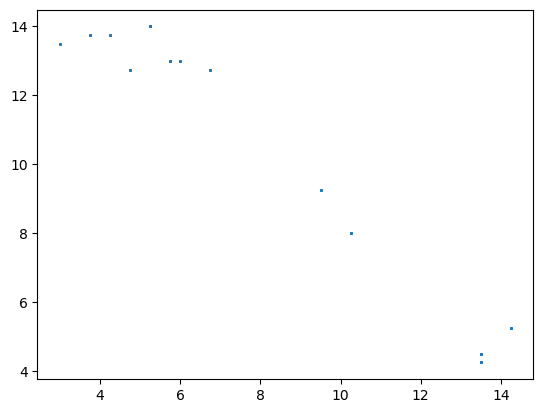

In [89]:
orient_square_gmm = np.abs(orient_square)
gmm = GaussianMixture(n_components=4)
gmm.fit(orient_square_gmm)
plt.scatter(orient_square_gmm[:,0], orient_square_gmm[:,1], s=1)    

(array([  8.,   0.,   0.,   0.,   4.,   4.,   0.,   0.,  12.,   3.,   0.,
          4.,  13.,   0.,   9.,  11.,   0.,   4.,   6.,   8.,  17.,  11.,
         20.,  17.,  30.,  25.,  46.,  29.,  40.,  64.,  55.,  38., 105.,
         67., 126., 135., 158., 157., 131., 194.,  80., 126., 103.]),
 array([-9.3758756 , -9.23701429, -9.09815299, -8.95929168, -8.82043038,
        -8.68156907, -8.54270777, -8.40384646, -8.26498516, -8.12612385,
        -7.98726255, -7.84840124, -7.70953994, -7.57067863, -7.43181733,
        -7.29295602, -7.15409472, -7.01523341, -6.87637211, -6.7375108 ,
        -6.5986495 , -6.45978819, -6.32092689, -6.18206558, -6.04320428,
        -5.90434297, -5.76548167, -5.62662036, -5.48775906, -5.34889775,
        -5.21003645, -5.07117515, -4.93231384, -4.79345254, -4.65459123,
        -4.51572993, -4.37686862, -4.23800732, -4.09914601, -3.96028471,
        -3.8214234 , -3.6825621 , -3.54370079, -3.40483949]),
 <BarContainer object of 43 artists>)

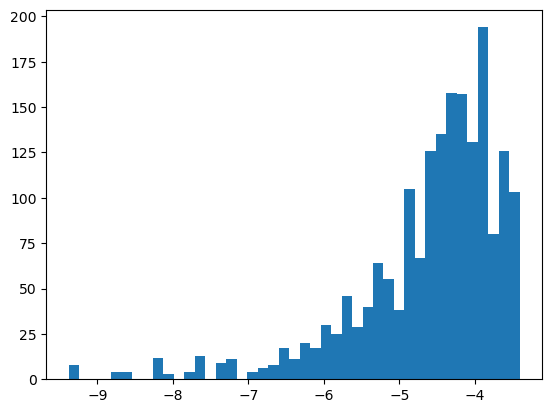

In [164]:
log_likelihood = gmm.score_samples(orient_square_gmm)
plt.hist(log_likelihood, bins=int(np.sqrt(len(orient_square_gmm))))

(array([359., 359., 296., 166., 135., 187., 200., 321., 227., 407., 427.,
        407., 283., 241., 162.,  99.,  86.,  30.,  39.,  23.]),
 array([54.01240855, 54.62980829, 55.24720803, 55.86460776, 56.4820075 ,
        57.09940724, 57.71680698, 58.33420671, 58.95160645, 59.56900619,
        60.18640592, 60.80380566, 61.4212054 , 62.03860513, 62.65600487,
        63.27340461, 63.89080434, 64.50820408, 65.12560382, 65.74300355,
        66.36040329]),
 <BarContainer object of 20 artists>)

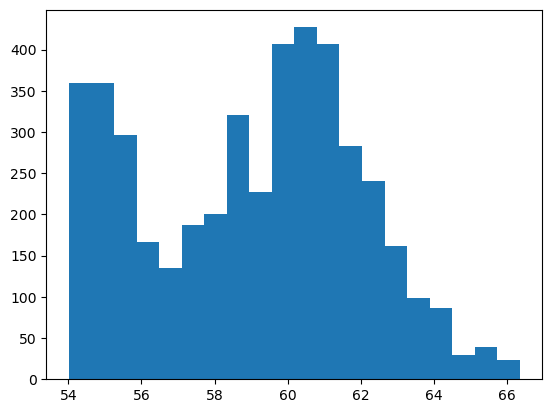

In [647]:
valid_length_buffer_square = np.array(valid_length_buffer_square)
valid_length_buffer = np.array(valid_length_buffer)
plt.hist(np.max(valid_length_buffer_square, axis=1), bins=20)

In [193]:
img_denote_sav = '-filter2'
# split_ind = '' #TODO define the split index
pth_load = f'CrCoNi-231101/{img_ind}/{img_ind}{img_denote_sav}{split_ind}.bmp'
img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay = img_color.copy()
alpha = 0.5

def trip_make(para_ind):
    tri_list = []
    for i in range(len(para_ind//2)):
        ind_para_ = np.unique(np.concatenate((
            para_ind[2*i], para_ind[2*i+1]
        )).reshape(-1,2), axis=0)
        tri_list.append(ind_para_)
    
    return tri_list

para_ind_35_t = np.unique(para_ind_35_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_35_v = np.unique(para_ind_35_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_50_t = np.unique(para_ind_50_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_50_v = np.unique(para_ind_50_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
square_ind_t = np.unique(square_ind_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
square_ind_v = np.unique(square_ind_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)

vertice_coord_all = np.concatenate((para_ind_35_t, para_ind_50_t, square_ind_t,
                                    para_ind_35_v, para_ind_50_v, square_ind_v), axis=0)


new_centre_list = np.round(new_centre_list, 0).astype(int)

#* Make bond tuples
bond_square_v, bond_square_t = [], []
for i in range(len(square_ind_t)):
    bond_square_t.append(tuple(square_ind_t[i]))
    bond_square_v.append(tuple(square_ind_v[i]))

bond_para_35_v, bond_para_35_t = [], []    
for j in range(len(para_ind_35_t)):
    bond_para_35_t.append(tuple(para_ind_35_t[j]))
    bond_para_35_v.append(tuple(para_ind_35_v[j]))

bond_para_50_v, bond_para_50_t = [], []
for k in range(len(para_ind_50_t)):
    bond_para_50_t.append(tuple(para_ind_50_t[k]))
    bond_para_50_v.append(tuple(para_ind_50_v[k]))

c_para_35 = (255, 161, 7)
c_para_50 = (0, 179, 255)
c_square = (69, 20, 255)

line_thickness_t = 2
line_thickness_v = 1
for bond_t, bond_v in zip(bond_square_t, bond_square_v):
    x1, y1, x2, y2 = bond_t
    x1_v, y1_v, x2_v, y2_v = bond_v
    cv2.line(img_color, (y1, x1), (y2, x2), c_square, line_thickness_t)
    cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_square, line_thickness_v)
    
for bond_t, bond_v in zip(bond_para_35_t, bond_para_35_v):
    x1, y1, x2, y2 = bond_t
    x1_v, y1_v, x2_v, y2_v = bond_v
    cv2.line(img_color, (y1, x1), (y2, x2), c_para_35, line_thickness_t)
    cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_para_35, line_thickness_v)
    
for bond_t, bond_v in zip(bond_para_50_t, bond_para_50_v):
    x1, y1, x2, y2 = bond_t
    x1_v, y1_v, x2_v, y2_v = bond_v
    cv2.line(img_color, (y1, x1), (y2, x2), c_para_50, line_thickness_t)
    cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_para_50, line_thickness_v)

img_color_raw = copy.deepcopy(img_color)
#* Draw dots 
radius = 2
thickness = 1
for (x, y) in new_centre_list:
    x, y =  int(round(x, 0)), int(round(y, 0))
    cv2.circle(img_color, (y,x), radius, (112,233,255), thickness)

sav_denote = ''
if not allow_dot_in_pattern:
    sav_denote = '_pure_polygon'

tolerant_threshold = False  #TODO if use tolerant threshold
if tolerant_threshold:
    sav_denote += '_tolerant'

cv2.addWeighted(overlay, alpha, img_color_raw, 1-alpha, 0, img_color_raw)
cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0, img_color)

cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line{sav_denote}{img_denote}{split_ind}.bmp', img_color)
cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line_raw{sav_denote}{img_denote}{split_ind}.bmp', img_color_raw)

print(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line{sav_denote}{img_denote}{split_ind}.bmp')

CrCoNi-231101/1/1_dotted_line_pure_polygon-filter2_22.bmp


Merge the images, do after all the subimages been processed.

In [195]:
img_ind = '1'
sav_denote = '_pure_polygon'
img_denote = '-filter2'
img_full = np.zeros((2048,2048,3))

for i, j in product(range(3), repeat=2):
    split_ind = f'_{i}{j}'
    img_load_pth = f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line{sav_denote}{img_denote}{split_ind}.bmp'
    img_ = cv2.imread(img_load_pth)
    pix_range = np.clip(np.array([700*i, 700*(i+1), 700*j, 700*(j+1)]),
                        0, 2048).astype(int)
    img_full[pix_range[0]:pix_range[1], pix_range[2]:pix_range[3],:] = img_
    
cv2.imwrite(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line{sav_denote}{img_denote}_fin.bmp', img_full)

True